In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

In [2]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

[ 0.00603285 -2.68434   ]
[ 2.67609000e-11 -1.48488944e-07  3.21750458e-04 -2.46472108e-01
  6.41689500e+01]
Mean Squared Error for the 1: 0.50
Mean Squared Error for the 2: 0.06


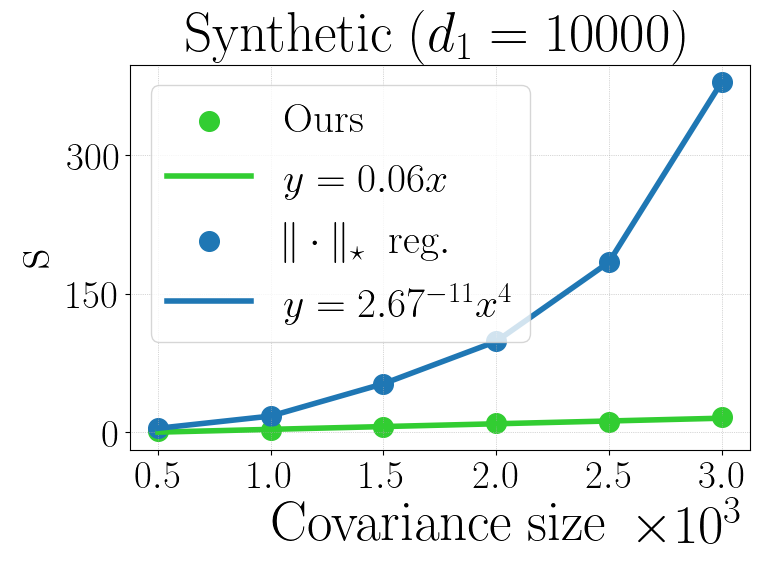

In [3]:
# observed entries
title = r'$\mathrm{Synthetic}~(d_1 = 10000)$'
X = np.array([500, 1000, 1500, 2000, 2500, 3000])
Y = np.array([1.0746, 4.5283, 10.7184, 16.8964, 26.6321, 43.725])
Y2 = np.array([1.0478, 2.9595,5.7688, 9.7734, 11.3796, 16.3098])
Ynu = np.array([4.4444,17.907,52.3507, 98.8649, 183.9492, 378.9757])
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
coefficients_1 = np.polyfit(X, Y2, deg=1)
model = np.poly1d(coefficients_1)
data_predict_1 = model(X)
print(coefficients_1)
coefficients_2 = np.polyfit(X, Ynu, deg=4)
model = np.poly1d(coefficients_2)
data_predict_2 = model(X)
print(coefficients_2)

mse_1 = np.mean((data_predict_1 - Y2) ** 2)
mse_2 = np.mean((data_predict_2 - Ynu) ** 2)
print("Mean Squared Error for the 1:", f"{mse_1:.2f}")
print("Mean Squared Error for the 2:", f"{mse_2:.2f}")


plt.figure(figsize=(8,5))

plt.scatter(X, Y2, s=200,color='limegreen', label=r'$\mathrm{Ours}$')
plt.plot(X, data_predict_1,color='limegreen',lw=4, label=r'$y = 0.06x$')
plt.scatter(X, Ynu, s=200, label=r'$\|\cdot\|_\star~~\mathrm{reg.}$')
plt.plot(X, data_predict_2,lw=4, label=r'$y = 2.67^{-11}x^4$')
#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
plt.legend(fontsize=30, loc='upper left', ncol=1)

plt.xlabel(r"$\mathrm{Covariance~size}$", fontsize=40)
plt.ylabel(r"$\mathrm{s}$", fontsize=40)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
#plt.yscale("log", base=10)
#plt.ylim(,1.1)
plt.ticklabel_format(style='sci', axis='x', scilimits=(3, 3))
plt.gca().xaxis.get_offset_text().set_fontsize(40)  

plt.gca().xaxis.set_major_locator(MaxNLocator(6))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
#plt.tight_layout()
plot_name = f"./plots/time_syn.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[ 2.65612844e-06 -3.38289633e+02]
[ 1.99828381e-12 -8.51621914e-04  9.18043905e+04]
Mean Squared Error for the 1: 2216.02
Mean Squared Error for the 2: 0.00


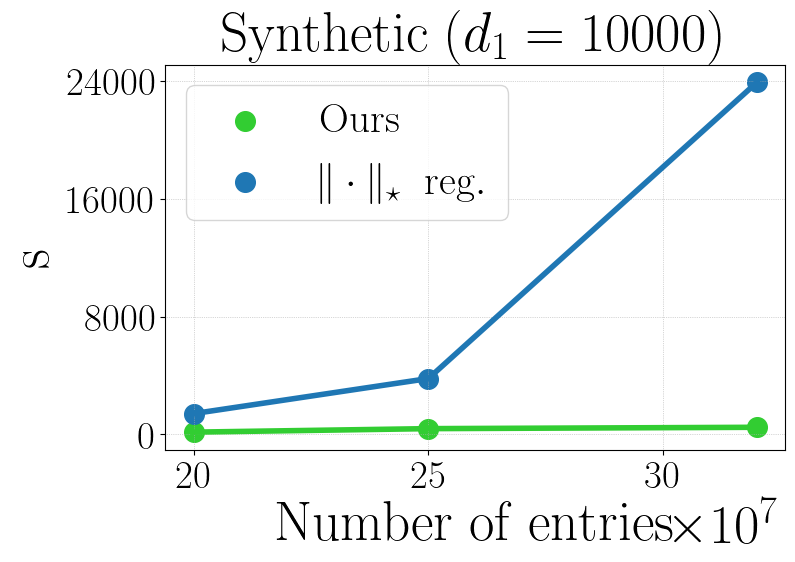

In [6]:
X = np.array([200000000, 250000000, 320000000])
X_pred = np.linspace(200000000, 320000000)
Y = np.array([154.28, 392.01, 484.06])
Y2 = np.array([1411.36, 3791.65,23909.64])
# observed entries
title = r'$\mathrm{Synthetic}~(d_1 = 10000)$'
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
coefficients_1 = np.polyfit(X, Y, deg=1)
model = np.poly1d(coefficients_1)
data_predict_1 = model(X)
print(coefficients_1)
coefficients_2 = np.polyfit(X, Y2, deg=2)
model = np.poly1d(coefficients_2)
data_predict_2 = model(X)
print(coefficients_2)
mse_1 = np.mean((data_predict_1 - Y) ** 2)
mse_2 = np.mean((data_predict_2 - Y2) ** 2)
print("Mean Squared Error for the 1:", f"{mse_1:.2f}")
print("Mean Squared Error for the 2:", f"{mse_2:.2f}")


plt.figure(figsize=(8,5))

plt.scatter(X, Y, s=200,color='limegreen', label=r'$\mathrm{Ours}$')
#plt.plot(X, data_predict_1,lw=4, label=r'$y = 5.88^{-6}x^2$')
plt.scatter(X, Y2, s=200, label=r'$\|\cdot\|_\star~~\mathrm{reg.}$')
plt.plot(X, Y, lw=4,color='limegreen')
#plt.plot(X, data_predict_1,lw=4, label=r'$y = 5.88^{-6}x^2$')
plt.plot(X, Y2, lw=4)
#plt.plot(X, data_predict_2,lw=4, label=r'$y = 6.03^{-3}x$')
#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
plt.legend(fontsize=30, loc='upper left', ncol=1)

plt.xlabel(r"$\mathrm{Number~of~entries}$", fontsize=40)
plt.ylabel(r"$\mathrm{s}$", fontsize=40)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
#plt.yscale("log", base=10)
#plt.ylim(,1.1)
plt.ticklabel_format(style='sci', axis='x', scilimits=(7, 7))
plt.gca().xaxis.get_offset_text().set_fontsize(40)  

plt.gca().xaxis.set_major_locator(MaxNLocator(3))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
#plt.tight_layout()
plot_name = f"./plots/time_real.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()